In [1]:
import anndata as ad
import os
import pandas as pd
import matplotlib.pyplot as plt

## Download results

In [2]:
def dict_to_pd(d):
    rows = []

    for outer_key, inner in d.items():
        row = {
            "dataset_id": inner["dataset_id"],
            "method_id": inner["method_id"],
        }
        
        # Use values from "d" as column names
        for col_name, value in zip(inner["metric_ids"], inner["metric_values"]):
            row[col_name] = value
            
        rows.append(row)
    
    df = pd.DataFrame(rows, index=d.keys())
    return df

In [3]:
methods_path = '../../data/benchmark/results/metrics/methods/'

In [5]:
file_name_err = 'mean_rowwise_error.h5ad'
file_name_corr = 'mean_rowwise_correlation.h5ad'

In [6]:
methods_err = {}
methods_corr = {}
for item in os.listdir(methods_path):
    if ('mol_emb_subsample' in item) and (not 'pca' in item):
        stability_path = methods_path + item + '/stability'
        for seed in os.listdir(stability_path):
            
            err = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_err}').uns
            corr = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_corr}').uns
            methods_err[item + '_' + seed] = err
            methods_corr[item + '_' + seed] = corr
            
    if ('mol_emb_subsample' in item) and (not 'pca' in item) and ('lpm' in item):
        stability_path = methods_path + item + '/stability_lpm_2000_256'
        for seed in os.listdir(stability_path):
            
            err = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_err}').uns
            corr = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_corr}').uns
            methods_err[item + '_' + '2000_256' + '_' + seed] = err
            methods_corr[item + '_' + '2000_256' + '_' + seed] = corr

    if ('mol_emb_subsample' in item) and (not 'pca' in item) and ('lpm' in item):
        stability_path = methods_path + item + '/stability_lpm_2000_512'
        for seed in os.listdir(stability_path):
            
            err = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_err}').uns
            corr = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_corr}').uns
            methods_err[item + '_' + '2000_512' + '_' + seed] = err
            methods_corr[item + '_' + '2000_512' + '_' + seed] = corr

In [7]:
df_method_err = dict_to_pd(methods_err)
df_method_corr = dict_to_pd(methods_corr)

In [8]:
df_method_err

,dataset_id,method_id,mean_rowwise_rmse,mean_rowwise_mae
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_trainable_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.774766,0.563483
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_trainable_seed_11,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.775462,0.564157
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_trainable_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.774431,0.563077
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_trainable_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.774697,0.563237
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_trainable_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.779060,0.566604
...,...,...,...,...
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_2000_512_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.780082,0.563525
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_2000_512_seed_14,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.779902,0.562765
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_2000_512_seed_12,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.780620,0.563828
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_2000_512_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.779786,0.562553


In [9]:
df_method_err['method_name'] = df_method_err.index.str.split('_seed_').str[0]
df_method_err['seed'] = df_method_err.index.str.split('_seed_').str[1].astype(int)
df_method_corr['method_name'] = df_method_corr.index.str.split('_seed_').str[0]
df_method_corr['seed'] = df_method_corr.index.str.split('_seed_').str[1].astype(int)

* **NB!** notations of LPM embeddings without additional suffixes mean we followed the original parameters in LPM model: dim of embedding layer is 128 and dim of hidden layers is 256.
* **NB!** Suffux `_2000_256` means embedding was obtained via training LPM model with dim of embedding layer 2000 and dim of hidden layers 256.
* **NB!** Suffux `_2000_512` means embedding was obtained via training LPM model with dim of embedding layer 2000 and dim of hidden layers 512.
* **NB!** dim of ECFP:2 is 2000.
* Results were obtained across 10 seeds.
</br>

* `none` - Original architecture of models without additional embedding information.
</br>

* `lpm_concat_not_dense` - concatenation of fixed LPM embedding with 2 trainable: cell type and small molecule embeddings, before concatenation **no** additional Dense layer was applied.
* `lpm_concat_dense` - concatenation of fixed LPM embedding with 2 trainable specified in the initial architecture of the models: cell type and small molecule embeddings, before concatenation LPM embedding was projected with an additional Dense layer.
* `lpm_fixed` - small molecule freezed embedding was initialized with LPM embedding information and then projected with a Dense layer to match original `emb_out` dimentions.
* `lpm_trainable` - small molecule unfreezed embedding was initialized with LPM embedding information and then projected with a Dense layer to match original `emb_out` dimentions.
</br>

* `fp_concat_not_dense` - concatenation of fixed ECFP:2 embedding with 2 trainable: cell type and small molecule embeddings, before concatenation **no** additional Dense layer was applied.
* `fp_concat_dense` - concatenation of fixed ECFP:2 embedding with 2 trainable: cell type and small molecule embeddings, before concatenation ECFP:2 embedding was projected with an additional Dense layer.
* `fp_fixed` - small molecule freezed embedding was initialized with ECFP:2 embedding information and then projected with a Dense layer to match original `emb_out` dimentions.
* `fp_trainable` - small molecule unfreezed embedding was initialized with ECFP:2 embedding information and then projected with a Dense layer to match original `emb_out` dimentions.

## Mean rowwise error

### Methods

In [10]:
df_method_err.sort_values(by="mean_rowwise_rmse")

,dataset_id,method_id,mean_rowwise_rmse,mean_rowwise_mae,method_name,seed
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_concat_dense_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_con...,0.771154,0.560883,nn_retraining_with_pseudolabels_mol_emb_subsam...,0
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_dense_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.771353,0.556989,nn_retraining_with_pseudolabels_mol_emb_subsam...,13
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.771371,0.558549,nn_retraining_with_pseudolabels_mol_emb_subsam...,1
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_fixed_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_fixed,0.771421,0.560991,nn_retraining_with_pseudolabels_mol_emb_subsam...,1
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_dense_seed_14,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.771740,0.557717,nn_retraining_with_pseudolabels_mol_emb_subsam...,14
...,...,...,...,...,...,...
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_dense_2000_512_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.782561,0.566661,nn_retraining_with_pseudolabels_mol_emb_subsam...,4
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_fixed_seed_14,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.782630,0.561253,nn_retraining_with_pseudolabels_mol_emb_subsam...,14
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_fixed_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.783277,0.561864,nn_retraining_with_pseudolabels_mol_emb_subsam...,4
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_fixed_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.783351,0.561434,nn_retraining_with_pseudolabels_mol_emb_subsam...,3


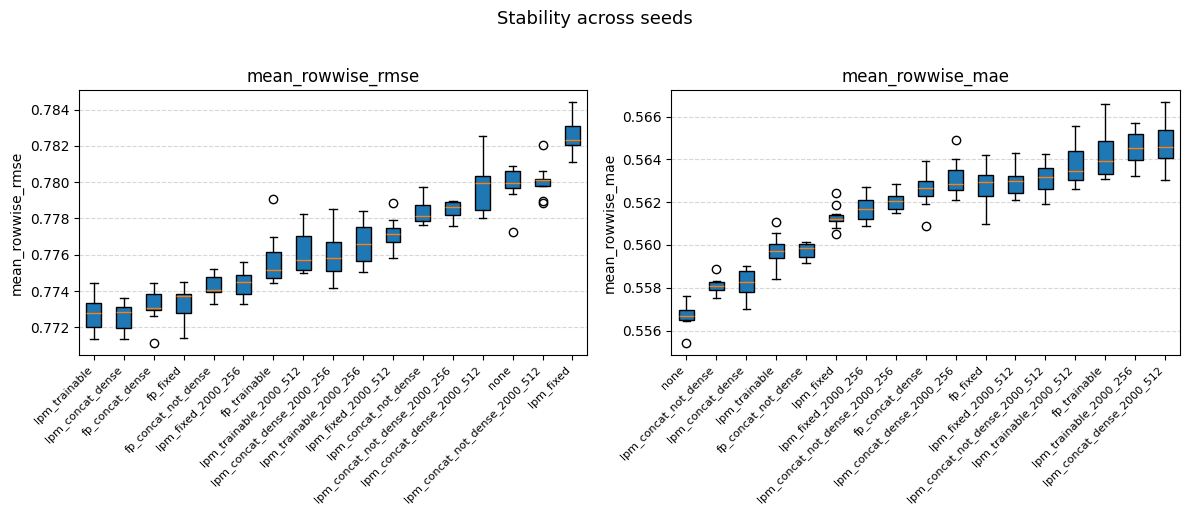

In [11]:
metrics = ["mean_rowwise_rmse", "mean_rowwise_mae"]
fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 5))
for ax, metric in zip(axes, metrics):
    # collect values per method, ordered by median
    methods_ordered = (
        df_method_err.groupby("method_name")[metric]
        .median()
        .sort_values()
        .index.tolist()
    )
    data_per_method = [
        df_method_err.loc[df_method_err["method_name"] == m, metric].values
        for m in methods_ordered
    ]
    bp = ax.boxplot(data_per_method, patch_artist=True, vert=True)
    ax.set_xticks(range(1, len(methods_ordered) + 1))
    ax.set_xticklabels(
        # strip the long common prefix for readability
        [m.replace("nn_retraining_with_pseudolabels_mol_emb_subsample_", "") for m in methods_ordered],
        rotation=45, ha="right", fontsize=8,
    )
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
fig.suptitle("Stability across seeds", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Mean rowwise correlation

### Methods

In [12]:
df_method_corr.sort_values(by="mean_rowwise_pearson", ascending=False)
#df_method_corr.sort_values(by="mean_rowwise_spearman", ascending=False)

,dataset_id,method_id,mean_rowwise_pearson,mean_rowwise_spearman,mean_rowwise_cosine,method_name,seed
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_2000_512_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.494677,0.464748,0.497618,nn_retraining_with_pseudolabels_mol_emb_subsam...,2
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.494524,0.464688,0.497521,nn_retraining_with_pseudolabels_mol_emb_subsam...,0
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.494247,0.464443,0.497263,nn_retraining_with_pseudolabels_mol_emb_subsam...,4
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.494070,0.464636,0.497025,nn_retraining_with_pseudolabels_mol_emb_subsam...,2
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_2000_512_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.494039,0.463852,0.497006,nn_retraining_with_pseudolabels_mol_emb_subsam...,0
...,...,...,...,...,...,...,...
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_2000_512_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.472418,0.445385,0.475557,nn_retraining_with_pseudolabels_mol_emb_subsam...,10
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_2000_256_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.472417,0.445541,0.475562,nn_retraining_with_pseudolabels_mol_emb_subsam...,10
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_2000_256_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.472236,0.444943,0.475410,nn_retraining_with_pseudolabels_mol_emb_subsam...,3
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_2000_512_seed_12,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.471830,0.444309,0.474999,nn_retraining_with_pseudolabels_mol_emb_subsam...,12


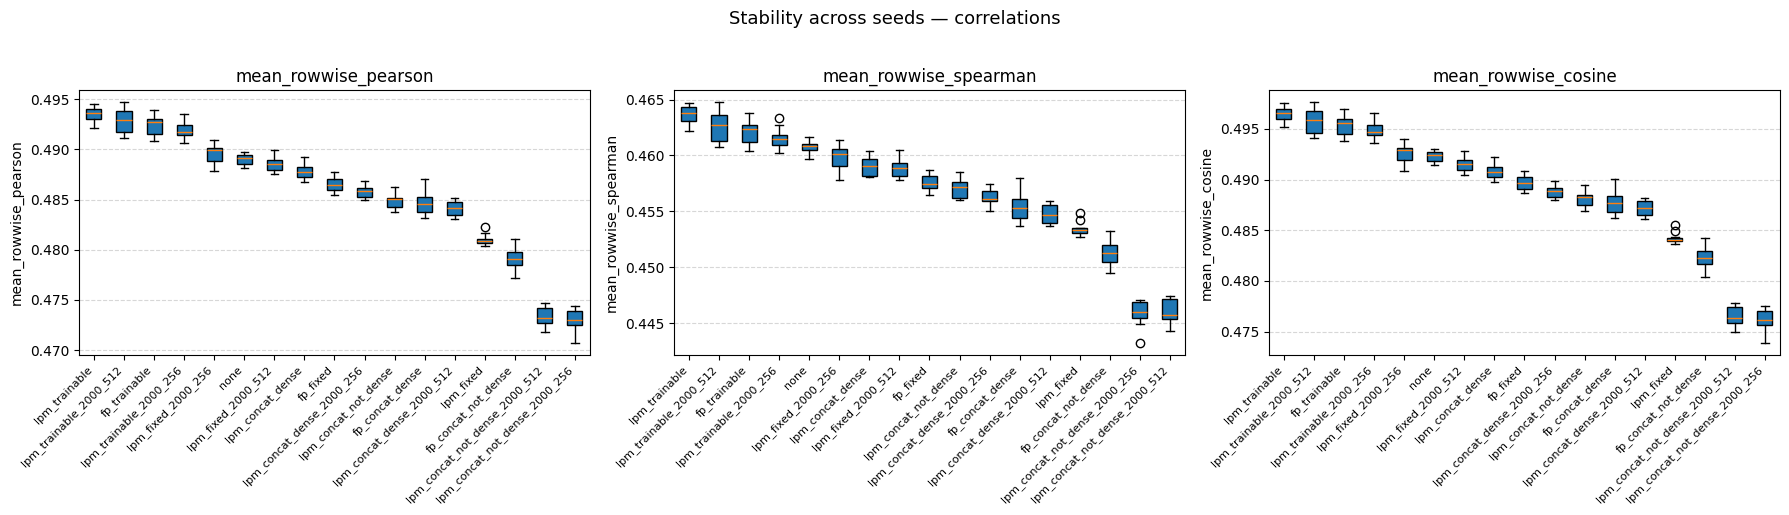

In [13]:
corr_metrics = ["mean_rowwise_pearson", "mean_rowwise_spearman", "mean_rowwise_cosine"]
fig, axes = plt.subplots(1, len(corr_metrics), figsize=(6 * len(corr_metrics), 5))
for ax, metric in zip(axes, corr_metrics):
    # higher correlation is better → sort descending
    methods_ordered = (
        df_method_corr.groupby("method_name")[metric]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )
    data_per_method = [
        df_method_corr.loc[df_method_corr["method_name"] == m, metric].values
        for m in methods_ordered
    ]
    bp = ax.boxplot(data_per_method, patch_artist=True, vert=True)
    ax.set_xticks(range(1, len(methods_ordered) + 1))
    ax.set_xticklabels(
        [m.replace("nn_retraining_with_pseudolabels_mol_emb_subsample_", "") for m in methods_ordered],
        rotation=45, ha="right", fontsize=8,
    )
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
fig.suptitle("Stability across seeds — correlations", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()